In [1]:
import os
import sys
import talib as ta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
%matplotlib inline
sns.set_theme()

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.Alpha9.utility import get_config, read_file

In [4]:
# read data for a specific crypto
i = 0
config = get_config.load()
symbols = config['pipeline']['symbols']
timeperiod_cat = config['pipeline']['timeperiod_cat']
timeperiod_cat0 = config['pipeline']['timeperiod_cat0']
timeperiod_cat1 = config['pipeline']['timeperiod_cat1']
timeperiod_cat2 = config['pipeline']['timeperiod_cat2']
timeperiod_cat3 = config['pipeline']['timeperiod_cat3']
timeperiod_cat4 = config['pipeline']['timeperiod_cat4']
data = read_file.read_data('raw', symbols[i])

In [5]:
open_px = data['open']
high_px = data['high']
low_px = data['low']
close_px = data['close']
vol = data['volume']

In [6]:
def ICHIMOKU(high_px, low_px, close_px, fastperiod, medperiod, slowperiod):
    tenkan = (ta.MAX(high_px, timeperiod=fastperiod) + ta.MIN(low_px, timeperiod=fastperiod)) / 2
    kijun = (ta.MAX(high_px, timeperiod=medperiod) + ta.MIN(low_px, timeperiod=medperiod)) / 2
    span_b = (ta.MAX(high_px, timeperiod=slowperiod) + ta.MIN(low_px, timeperiod=slowperiod)) / 2
    cloud_trend = (close_px - span_b) / close_px
    tk_cross = (tenkan - kijun) / close_px
    return cloud_trend, tk_cross

In [7]:
def VWAP(high_px, low_px, close_px, vol, period):
    typical_price = (high_px + low_px + close_px) / 3
    pv = typical_price * vol
    pv_sum = pv.rolling(window=period, min_periods=period).sum()
    vol_sum = vol.rolling(window=period, min_periods=period).sum()

    return pv_sum / vol_sum

In [8]:
# trend indicators
data['sma-dist'] = (close_px - ta.SMA(close_px, timeperiod=timeperiod_cat4)) / ta.SMA(close_px, timeperiod=timeperiod_cat4)
data['ema-dist'] = (close_px - ta.EMA(close_px, timeperiod=timeperiod_cat3)) / ta.EMA(close_px, timeperiod=timeperiod_cat3)
macd, macdsignal, macdhist = ta.MACD(close_px, fastperiod=timeperiod_cat1, slowperiod=timeperiod_cat3, signalperiod=timeperiod_cat0)
data['macd-signal-pct'] = (macd - macdsignal) / close_px
data['macd-slope'] = macd.diff()
data['trix'] = ta.TRIX(close_px, timeperiod=timeperiod_cat2)
data['sar'] = (close_px - ta.SAR(high_px, low_px)) / close_px
data['tema'] = (close_px - ta.TEMA(close_px, timeperiod=timeperiod_cat2)) / ta.TEMA(close_px, timeperiod=timeperiod_cat2)
data['trima'] = ta.TRIMA(close_px, timeperiod=timeperiod_cat4)
data['wma'] = ta.WMA(close_px, timeperiod=timeperiod_cat3)
data['dema'] = (close_px - ta.DEMA(close_px, timeperiod=timeperiod_cat4)) / ta.DEMA(close_px, timeperiod=timeperiod_cat4)
data['ppo'] = ta.PPO(close_px, fastperiod=timeperiod_cat1, slowperiod=timeperiod_cat3)
data['plus-di'] = ta.PLUS_DI(high_px, low_px, close_px, timeperiod=timeperiod_cat0)
data['minus-di'] = ta.MINUS_DI(high_px, low_px, close_px, timeperiod=timeperiod_cat0)
data['lin-reg-slope'] = ta.LINEARREG_SLOPE(close_px, timeperiod=timeperiod_cat2)
data['ichi-cloud-trend'], data['ichi-tk-cross'] = ICHIMOKU(high_px, low_px, close_px, timeperiod_cat0, timeperiod_cat3, timeperiod_cat4)

# momentum indicators
data['rsi'] = ta.RSI(close_px, timeperiod=timeperiod_cat2)
data['stoch-osc-slowk'], data['stoch-osc-slowd'] = ta.STOCH(high_px, low_px, close_px, fastk_period=timeperiod_cat2, slowk_period=timeperiod_cat, slowd_period=timeperiod_cat)
data['adx'] = ta.ADX(high_px, low_px, close_px, timeperiod=timeperiod_cat2)
data['momentum'] = ta.MOM(close_px, timeperiod=timeperiod_cat2)
data['cci'] = ta.CCI(high_px, low_px, close_px, timeperiod=timeperiod_cat2)
data['cmo'] = ta.CMO(close_px, timeperiod=timeperiod_cat2)
fastk, fastd = ta.STOCHRSI(close_px, timeperiod=timeperiod_cat2, fastk_period=timeperiod_cat2, fastd_period=timeperiod_cat)
data['stoch-rsi'] = fastk - fastd
data['williams-%r'] = ta.WILLR(high_px, low_px, close_px, timeperiod=timeperiod_cat2)
data['bop'] = ta.BOP(open_px, high_px, low_px, close_px)

# volatility indicators
data['natr'] = ta.NATR(high_px, low_px, close_px, timeperiod=timeperiod_cat2)
upper, middle, lower = ta.BBANDS(close_px, timeperiod=timeperiod_cat3)
data['bbands_pct'] = (close_px - lower) / (upper - lower)
data['bbands_width'] = (upper - lower) / middle
data['std-dev'] = ta.STDDEV(np.log(close_px), timeperiod=timeperiod_cat3)

# volume indicators
data['obv'] = ta.OBV(close_px, vol)
data['vwap'] = VWAP(high_px, low_px, close_px, vol, timeperiod_cat3)
data['mfi'] = ta.MFI(high_px, low_px, close_px, vol, timeperiod=timeperiod_cat2)
data['ad-line'] = ta.AD(high_px, low_px, close_px, vol)

# basic indicators
data['log-return'] = (np.log(close_px / close_px.shift(1)))
data['vol-spike'] = (vol - vol.rolling(timeperiod_cat2).mean()) / vol.rolling(timeperiod_cat2).mean()
data['norm-volatility'] = ((high_px - low_px) / close_px)

In [9]:
data.dropna(inplace=True)
data

,open,high,low,close,volume,sma-dist,ema-dist,macd-signal-pct,macd-slope,trix,...,bbands_pct,bbands_width,std-dev,obv,vwap,mfi,ad-line,log-return,vol-spike,norm-volatility
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-06-05 02:00:00,17.5738,17.5996,17.5131,17.5272,100178.580,0.005434,0.001982,0.000345,-0.000360,0.012734,...,0.596248,0.017404,0.004362,2.416078e+06,17.504610,64.026515,1.618690e+06,-0.002815,-0.005011,0.004935
2020-06-05 03:00:00,17.5243,17.5769,17.4738,17.5303,86134.480,0.005218,0.001999,0.000263,-0.000278,0.013743,...,0.611040,0.017249,0.004323,2.502213e+06,17.499244,57.551619,1.626961e+06,0.000177,-0.137056,0.005881
2020-06-05 04:00:00,17.5302,17.5815,17.4580,17.5160,75172.650,0.003976,0.001094,0.000138,-0.001599,0.014300,...,0.574492,0.016796,0.004210,2.427040e+06,17.496013,51.588753,1.622396e+06,-0.000816,-0.237618,0.007051
2020-06-05 05:00:00,17.5189,17.7700,17.5160,17.7523,165487.730,0.016845,0.013504,0.000892,0.017375,0.017708,...,1.231928,0.019720,0.004930,2.592528e+06,17.502418,53.598213,1.764820e+06,0.013400,0.610377,0.014308
2020-06-05 06:00:00,17.7536,17.8340,17.6600,17.8090,107270.820,0.019330,0.015481,0.001507,0.017715,0.023530,...,1.210617,0.023942,0.005974,2.699799e+06,17.512766,54.021537,1.841266e+06,0.003189,0.035400,0.009770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,862.0100,864.8100,862.0100,864.3200,5782.264,0.005740,0.001464,-0.000770,-0.065471,0.030547,...,0.579845,0.014529,0.003630,7.811569e+07,864.694576,66.993430,1.550064e+08,0.002676,-0.259577,0.003240
2025-12-31 20:00:00,864.3100,864.4800,860.8400,863.4900,8788.477,0.004502,0.000465,-0.000737,-0.129675,0.027440,...,0.503999,0.014258,0.003562,7.810690e+07,864.655031,58.139522,1.550104e+08,-0.000961,0.148295,0.004215
2025-12-31 21:00:00,863.4900,866.3800,863.4800,866.0000,2182.315,0.007118,0.003123,-0.000507,0.087939,0.025170,...,0.691731,0.014012,0.003502,7.810908e+07,864.798990,55.470594,1.550120e+08,0.002903,-0.696718,0.003349


In [10]:
def plot_heatmap(corr_matrix):
    plt.figure(figsize=(20, 16))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        vmin=-1, vmax=1,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )

    plt.title("Correlation Matrix - Features", fontsize=16, color='blue')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [15]:
def evaluate_feature(data, features):
    results = []

    # plot correlation heatmap
    plot_heatmap(data[features].corr())

    # calculate metrics
    for feature in features:
        result = {'Feature' : feature}

        momentum_indicators = ['rsi', 'stoch-osc', 'adx', 'momentum', 'cmo', 'stoch-rsi', 'williams-%r', 'bop']
        volatility_indicators = ['natr', 'bbands_pct', 'bbands_width', 'std-dev']
        volume_indicators = ['obv', 'vwap', 'mfi', 'ad-line']
        basic_indicators = ['log-return', 'vol-spike', 'norm-volatility']

        if feature in momentum_indicators:
            result['Type'] = 'Momentum'
        elif feature in volatility_indicators:
            result['Type'] = 'Volatility'
        elif feature in volume_indicators:
            result['Type'] = 'Volume'
        else:
            result['Type'] = 'Trend'

        # calculate redundancy score
        corr = data[features].corrwith(data[feature])
        others = corr.drop(feature)
        result['Redundancy Score'] = np.linalg.norm(others)

        # calculate stationarity
        adf = adfuller(data[feature].values)
        result['Stationarity Value'] = f'{adf[1]:.5}'

        results.append(result)

    return results

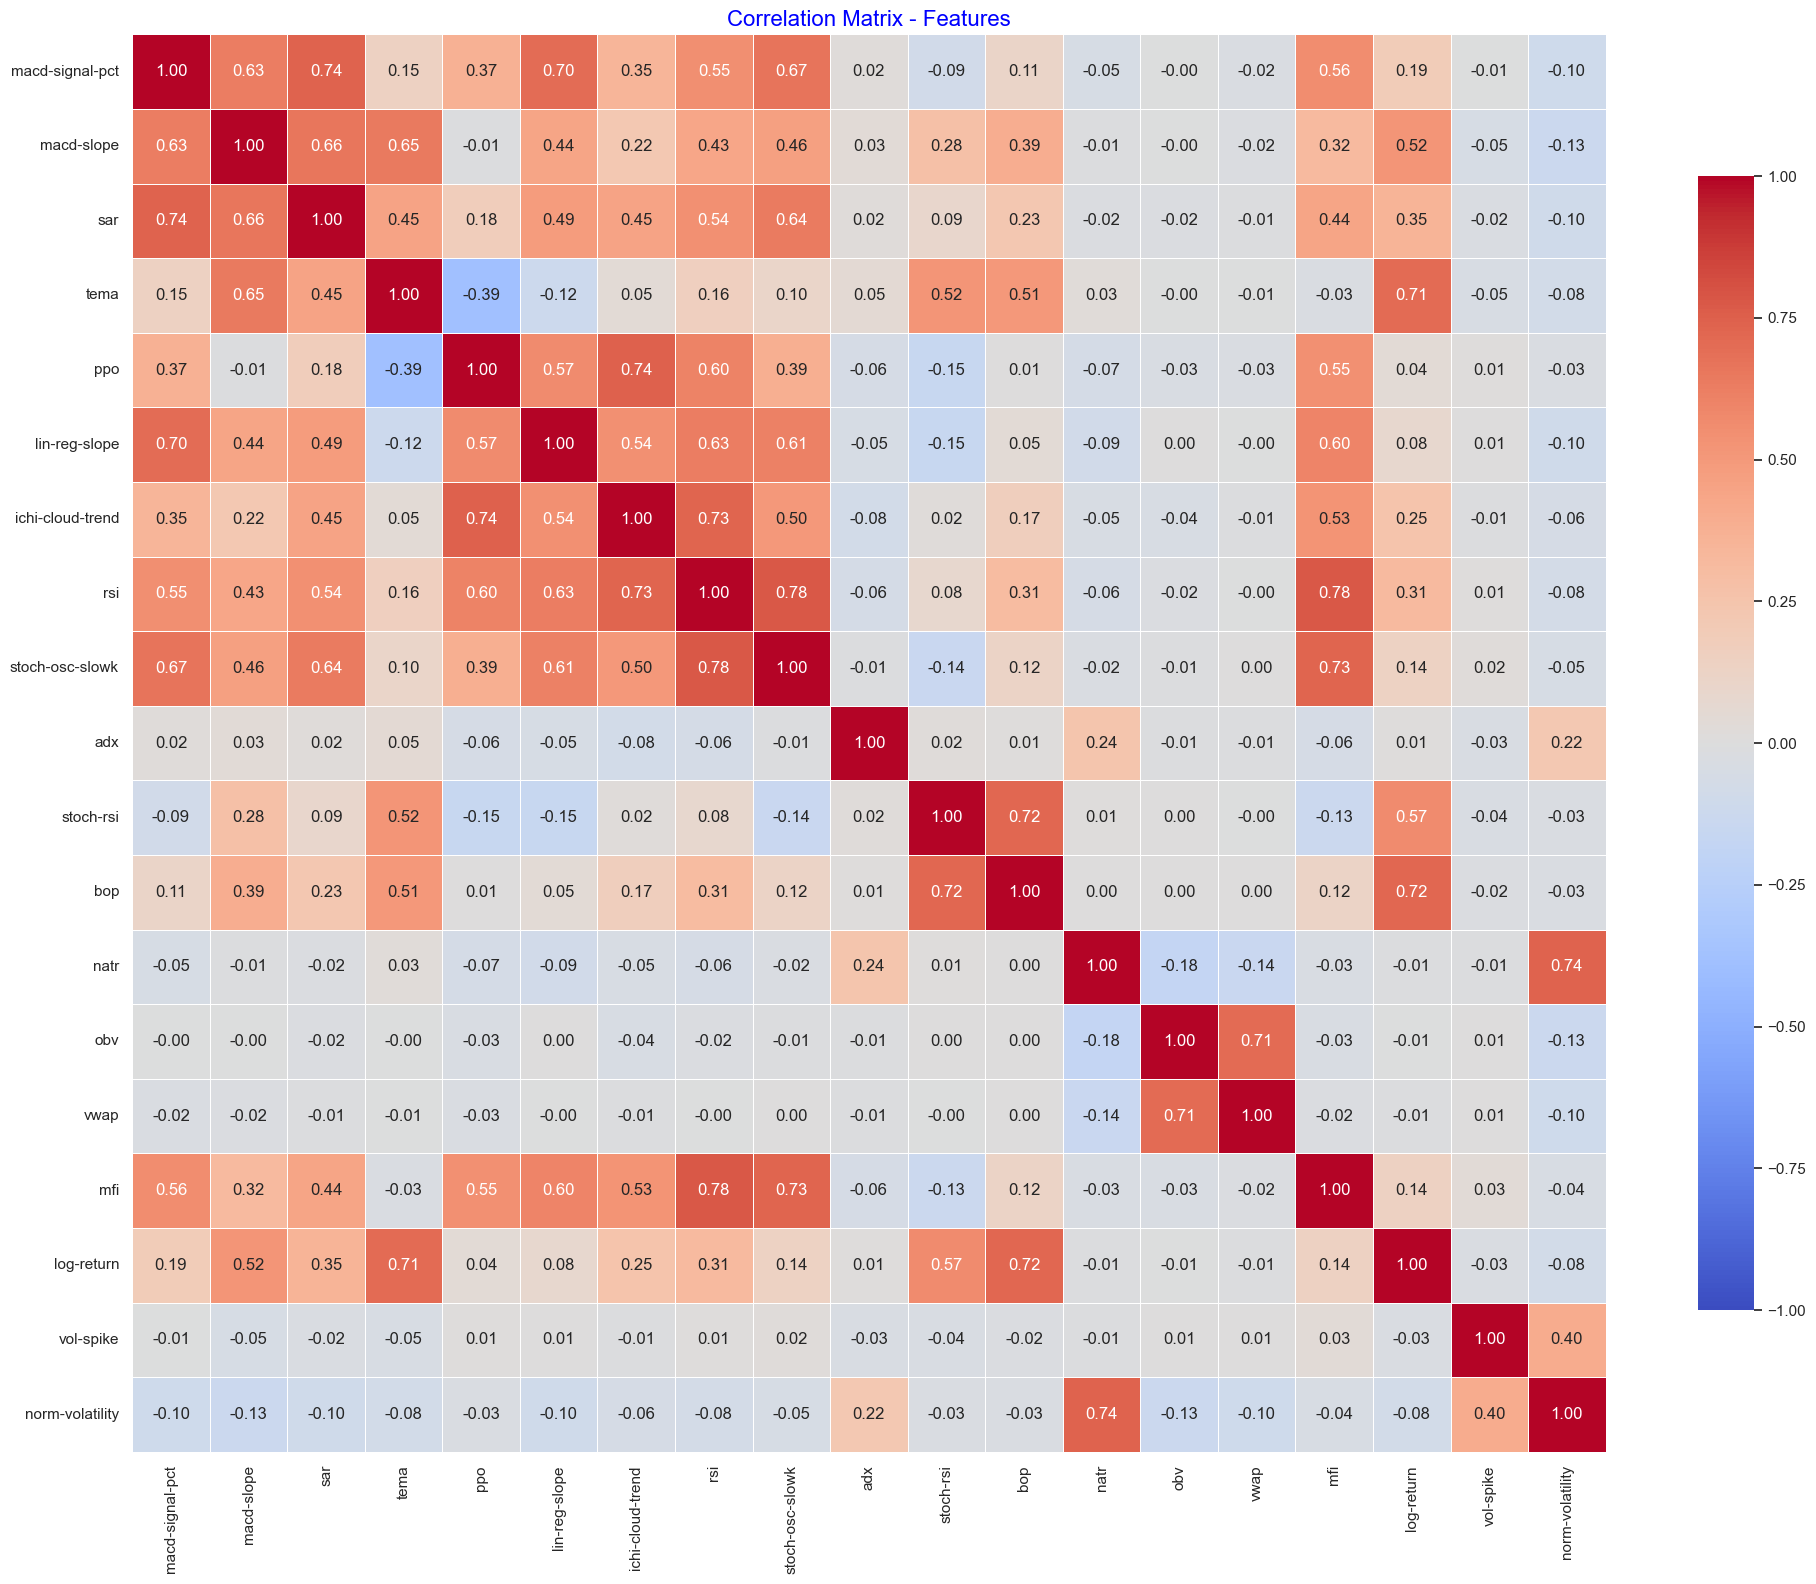

In [16]:
features = list(data.columns)
removed = ['open', 'high', 'low', 'close', 'volume', 'cmo', 'trima', 'wma', 'bbands_width', 'ad-line', 'stoch-osc-slowd', 'williams-%r', 'sma-dist', 'bbands_pct', 'momentum', 'plus-di', 'minus-di', 'ema-dist', 'dema', 'trix', 'std-dev', 'cci', 'ichi-tk-cross']
features = [feature for feature in features if feature not in removed]
# features = ['momentum', 'ichi-cloud-trend', 'cci', 'sma-dist', 'trima', 'ema-dist', 'macd-signal-pct', 'ppo', 'williams-%r', 'macd-slope']
result = evaluate_feature(data, features)

In [17]:
result_df = pd.DataFrame(result)
print(result_df.describe())

       Redundancy Score
count         19.000000
mean           1.266592
std            0.464808
min            0.366943
25%            0.876771
50%            1.413465
75%            1.653405
max            1.880171


In [18]:
result_sorted_df = result_df.sort_values(by=['Redundancy Score'], ascending=False)
print(result_sorted_df)

             Feature        Type  Redundancy Score Stationarity Value
7                rsi    Momentum          1.880171                0.0
8    stoch-osc-slowk       Trend          1.748913                0.0
0    macd-signal-pct       Trend          1.685374                0.0
2                sar       Trend          1.656130                0.0
15               mfi      Volume          1.655667                0.0
5      lin-reg-slope       Trend          1.651143                0.0
1         macd-slope       Trend          1.583370                0.0
6   ichi-cloud-trend       Trend          1.546715                0.0
4                ppo       Trend          1.427882                0.0
16        log-return       Trend          1.413465                0.0
3               tema       Trend          1.371701                0.0
11               bop    Momentum          1.294161                0.0
10         stoch-rsi    Momentum          1.136716                0.0
18   norm-volatility